In [47]:
#Najpierw wczytamy dane dla listopada 2024 roku
import pandas as pd
df1 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202411-citibike-tripdata_1.csv")
df2 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202411-citibike-tripdata_2.csv")
df3 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202411-citibike-tripdata_3.csv")
df4 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202411-citibike-tripdata_4.csv")
print(df1.head())

C:\Users\kacpe\AppData\Local\Temp\ipykernel_19168\980222256.py:3: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202411-citibike-tripdata_1.csv")
C:\Users\kacpe\AppData\Local\Temp\ipykernel_19168\980222256.py:4: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202411-citibike-tripdata_2.csv")
C:\Users\kacpe\AppData\Local\Temp\ipykernel_19168\980222256.py:5: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv("C:\\Users\\kacpe\\OneDrive\\Dokumenty\\APolitechnika\\Projekty\\Projekt_koncowy_PDU\\202411-

            ride_id  rideable_type               started_at  \
0  385B674CAB863CFD  electric_bike  2024-11-04 16:20:39.631   
1  F2EF2F3D1965E820  electric_bike  2024-11-01 07:11:31.922   
2  5B9FF4A9ABE1A129  electric_bike  2024-11-03 18:27:44.598   
3  A8764C2026DF1341  electric_bike  2024-11-03 11:24:05.945   
4  BDB5C9303C6E77F9  electric_bike  2024-11-10 12:30:14.282   

                  ended_at         start_station_name start_station_id  \
0  2024-11-04 16:25:59.455  Kent St & McGuinness Blvd          5785.10   
1  2024-11-01 07:16:23.862  Kent St & McGuinness Blvd          5785.10   
2  2024-11-03 18:31:49.389              58 St & 2 Ave          3138.09   
3  2024-11-03 11:28:40.045              41 St & 4 Ave          3347.03   
4  2024-11-10 12:58:33.456       Church St & Worth St          5359.13   

          end_station_name end_station_id  start_lat  start_lng    end_lat  \
0  Franklin St & Dupont St        5944.01  40.731240 -73.951610  40.735640   
1  Franklin St & Dup

In [48]:
#Łączenie data frameów w jeden
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
print(df.head())

            ride_id  rideable_type               started_at  \
0  385B674CAB863CFD  electric_bike  2024-11-04 16:20:39.631   
1  F2EF2F3D1965E820  electric_bike  2024-11-01 07:11:31.922   
2  5B9FF4A9ABE1A129  electric_bike  2024-11-03 18:27:44.598   
3  A8764C2026DF1341  electric_bike  2024-11-03 11:24:05.945   
4  BDB5C9303C6E77F9  electric_bike  2024-11-10 12:30:14.282   

                  ended_at         start_station_name start_station_id  \
0  2024-11-04 16:25:59.455  Kent St & McGuinness Blvd          5785.10   
1  2024-11-01 07:16:23.862  Kent St & McGuinness Blvd          5785.10   
2  2024-11-03 18:31:49.389              58 St & 2 Ave          3138.09   
3  2024-11-03 11:28:40.045              41 St & 4 Ave          3347.03   
4  2024-11-10 12:58:33.456       Church St & Worth St          5359.13   

          end_station_name end_station_id  start_lat  start_lng    end_lat  \
0  Franklin St & Dupont St        5944.01  40.731240 -73.951610  40.735640   
1  Franklin St & Dup

In [49]:
#Teraz stworzę 2 nowe kolumny z godziną oraz dniem tygodnia
#Upewniamy się czy pandas widzi daty jako daty a nie stringi
print(df.dtypes)
#Okazuje się że jako stringi, zatem konwertujemy je na daty
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
#Sprawdźmy czy się udało - tak, jak widzać poniżej
print(df.dtypes)

ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id       object
end_station_name          str
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object
ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id              object
end_station_name                 str
end_station_id                object
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
dtype: object


In [50]:
#Teraz możemy stworzyć nowe kolumny z godziną i dniem tygodnia
df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.day_name()
#Jak widać poniżej, udało się
print(df.head())

            ride_id  rideable_type              started_at  \
0  385B674CAB863CFD  electric_bike 2024-11-04 16:20:39.631   
1  F2EF2F3D1965E820  electric_bike 2024-11-01 07:11:31.922   
2  5B9FF4A9ABE1A129  electric_bike 2024-11-03 18:27:44.598   
3  A8764C2026DF1341  electric_bike 2024-11-03 11:24:05.945   
4  BDB5C9303C6E77F9  electric_bike 2024-11-10 12:30:14.282   

                 ended_at         start_station_name start_station_id  \
0 2024-11-04 16:25:59.455  Kent St & McGuinness Blvd          5785.10   
1 2024-11-01 07:16:23.862  Kent St & McGuinness Blvd          5785.10   
2 2024-11-03 18:31:49.389              58 St & 2 Ave          3138.09   
3 2024-11-03 11:28:40.045              41 St & 4 Ave          3347.03   
4 2024-11-10 12:58:33.456       Church St & Worth St          5359.13   

          end_station_name end_station_id  start_lat  start_lng    end_lat  \
0  Franklin St & Dupont St        5944.01  40.731240 -73.951610  40.735640   
1  Franklin St & Dupont St      

In [51]:
#Teraz odfiltrujemy tylko te wiersze, gdzie mamy wtorek i odfiltrujemy godziny po 15
df = df[(df['day_of_week'] == 'Tuesday') & (df['hour'] >= 15)]
#Teraz dodamy jeszcze jedną kolumnę, która będzie pokazywała różnicę w minutach między godziną wypożyczenia a godziną 15:00.
data_basic = pd.Timestamp(year=2024, month=11, day=5, hour=15)
df["Time_difference"] = (((df["started_at"] - data_basic).dt.total_seconds()%86400 )/60)
df["Time_difference"] = df["Time_difference"] - df["Time_difference"]%5
print(df.head(20))

              ride_id  rideable_type              started_at  \
15   1F45507E93FBA24B  electric_bike 2024-11-12 17:47:01.760   
39   D01A353BB6DAD883  electric_bike 2024-11-05 20:59:01.493   
44   D2C1D783E29AC612  electric_bike 2024-11-12 16:15:17.489   
45   FEC7230DF7A6212A  electric_bike 2024-11-05 16:07:30.928   
49   BD341F63B38520D9   classic_bike 2024-11-12 17:03:59.679   
76   A4491C3CA3864B72   classic_bike 2024-11-12 21:34:00.581   
80   AE40E45740E94D61  electric_bike 2024-11-12 16:14:03.675   
104  099ADCE2C61F0CE1  electric_bike 2024-11-05 17:55:31.824   
106  2F2795F881CCEAEE  electric_bike 2024-11-05 16:41:58.649   
111  5F3BAACF46583C5D  electric_bike 2024-11-05 18:48:10.215   
115  C4D36EC0F1BC3588  electric_bike 2024-11-05 17:14:42.261   
117  0C425BB9A0F30D33   classic_bike 2024-11-05 20:34:24.882   
141  6C3D58FD347DE09D  electric_bike 2024-11-12 18:09:02.741   
196  F0D32A95D817F517  electric_bike 2024-11-05 17:31:18.505   
197  1CE04965CB6F43D4  electric_bike 202

In [52]:
#Najpierw wyodrębnimy tylko te wiersze, które dotyczą wieczoru wyborczegpo, czyli 5 listopada 2024 roku
df["day"] = df["started_at"].dt.day
df_elective = df[df["day"] == 5]
df_non_elective = df[df["day"] != 5]
print(df_elective.head())

              ride_id  rideable_type              started_at  \
39   D01A353BB6DAD883  electric_bike 2024-11-05 20:59:01.493   
45   FEC7230DF7A6212A  electric_bike 2024-11-05 16:07:30.928   
104  099ADCE2C61F0CE1  electric_bike 2024-11-05 17:55:31.824   
106  2F2795F881CCEAEE  electric_bike 2024-11-05 16:41:58.649   
111  5F3BAACF46583C5D  electric_bike 2024-11-05 18:48:10.215   

                   ended_at                   start_station_name  \
39  2024-11-05 21:07:42.760  Adam Clayton Powell Blvd & W 141 St   
45  2024-11-05 16:30:17.239                     E 103 St & 2 Ave   
104 2024-11-05 18:04:20.361                  Mott St & Prince St   
106 2024-11-05 16:56:49.145                     5 St & Market St   
111 2024-11-05 18:59:30.352      Columbia Heights & Cranberry St   

    start_station_id          end_station_name end_station_id  start_lat  \
39           7893.05  Amsterdam Ave & W 125 St        7800.03  40.819241   
45           7436.16   Allen St & Rivington St        

In [53]:
Number_after_15_elective = df_elective.groupby('Time_difference').size().reset_index(name='liczba_wypozyczen')
Number_after_15_nonelective = df_non_elective.groupby('Time_difference').size().reset_index(name='liczba_wypozyczen')
Number_after_15_nonelective["liczba_wypozyczen"] = Number_after_15_nonelective["liczba_wypozyczen"]/3
print(Number_after_15_elective)

     Time_difference  liczba_wypozyczen
0                0.0                849
1                5.0                887
2               10.0                887
3               15.0                843
4               20.0                906
..               ...                ...
103            515.0                290
104            520.0                281
105            525.0                232
106            530.0                180
107            535.0                227

[108 rows x 2 columns]


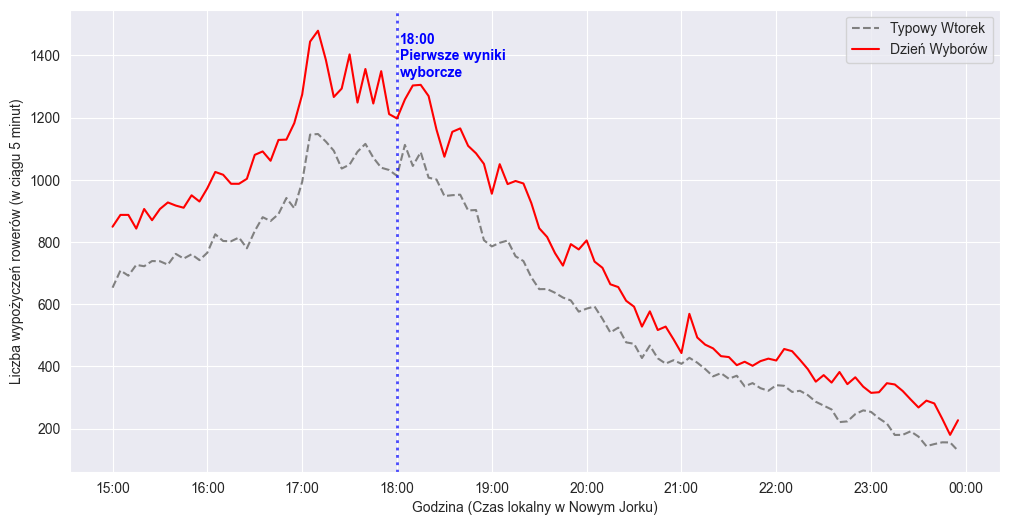

In [54]:
#Rysowanie wykresu
import matplotlib.pyplot as plt

# 1. Tworzenie czystego wykresu
plt.figure(figsize=(12, 6))

# 2. Rysowanie linii bazowej (szara, przerywana)
plt.plot(Number_after_15_nonelective['Time_difference'], Number_after_15_nonelective['liczba_wypozyczen'],
         color='gray', linestyle='--', label='Typowy Wtorek')

# 2. Pionowa linia (Godzina 18:00 = 180 minuta)
plt.axvline(x=180, color='blue', linestyle=':', alpha=0.7, linewidth=2)

# TEKST NA SAMEJ GÓRZE:
# x=182 (współrzędna osi X), y=0.95 (95% wysokości wykresu)
plt.text(182, 0.95, '18:00\nPierwsze wyniki\nwyborcze',
         color='blue', fontweight='bold', verticalalignment='top',
         transform=plt.gca().get_xaxis_transform())

# 3. Rysowanie linii dnia wyborów (czerwona)
plt.plot(Number_after_15_elective['Time_difference'], Number_after_15_elective['liczba_wypozyczen'],
         color='red', label='Dzień Wyborów')

#Przerabianie indeksowania osi x na ludzki
punkty_x = [0, 60, 120, 180, 240, 300, 360, 420, 480, 540]
godziny_etykiety = ['15:00', '16:00', '17:00', '18:00', '19:00', '20:00', '21:00', '22:00', '23:00', '00:00']
plt.xticks(punkty_x, godziny_etykiety)
#Dodanie opisu osi
plt.xlabel('Godzina (Czas lokalny w Nowym Jorku)')
plt.ylabel('Liczba wypożyczeń rowerów (w ciągu 5 minut)')

# 4. Podstawowe elementy (legenda i pokazanie wykresu)
plt.legend()
plt.show()